# Deep Learning Benchmark — LSTM and GRU

This notebook implements, trains, and evaluates two deep learning benchmark models: Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU). Both models are trained on the same four datasets used in `strategy_evaluation.ipynb` and evaluated on the identical held-out test sets. Results are saved for final comparison with the rule-based strategies in Section 7.

## Section 1 — Setup

In [ ]:
import sys
import os
import shutil
import importlib

# Reliable Colab detection
try:
    import google.colab
    IN_COLAB = os.path.isdir("/content")
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/My Drive/FX"
else:
    _cwd = os.path.abspath(os.getcwd())
    ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Purge __pycache__ so Colab always uses fresh source, not stale .pyc
for _d in ["", "models", "strategies", "utils"]:
    _cache = os.path.join(ROOT, _d, "__pycache__")
    if os.path.isdir(_cache):
        shutil.rmtree(_cache)
importlib.invalidate_caches()

# Delete old .keras checkpoints from a previous GPU type
_models_dir = os.path.join(ROOT, "results", "models")
if os.path.isdir(_models_dir):
    for _f in os.listdir(_models_dir):
        if _f.endswith(".keras"):
            os.remove(os.path.join(_models_dir, _f))
            print(f"Removed old checkpoint: {_f}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from config import (
    PROCESSED_DIR, TABLES_DIR, FIGURES_DIR,
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    SEQUENCE_LENGTH as SEQ_LEN,
    INPUT_DIM,
    HIDDEN_DIM, DROPOUT, LR, BATCH_SIZE, MAX_EPOCHS, PATIENCE,
    FEATURE_NAMES, SIGNIFICANCE_THRESHOLD,
    FLOPS_MA, FLOPS_RSI, FLOPS_VB, FLOPS_LSTM, FLOPS_GRU,
    LATENCY_ITERATIONS,
)

from models.lstm_model import (
    build_model       as build_lstm,
    prepare_sequences as prepare_sequences_lstm,
    train             as train_lstm,
    evaluate          as evaluate_lstm,
)
from models.gru_model import (
    build_model       as build_gru,
    prepare_sequences as prepare_sequences_gru,
    train             as train_gru,
    evaluate          as evaluate_gru,
)

# Ensure all output directories exist
import subprocess
subprocess.run([sys.executable, os.path.join(ROOT, "setup.py")], check=True)

plt.style.use("seaborn-v0_8")

env = "Google Colab" if IN_COLAB else "Local"
print(f"TensorFlow version: {tf.__version__}")
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print(f"Setup complete. Environment: {env}")
print(f"Project root: {ROOT}")

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup complete. Environment: Google Colab
Project root: /content/drive/My Drive/FX


## Section 2 — Load Processed Datasets

The four processed datasets (EURUSD 15-minute, EURUSD 1-hour, GBPUSD 15-minute, GBPUSD 1-hour) are loaded from `data/processed/`. Each dataset is then partitioned into train, validation, and test sets using the same **chronological 70 / 15 / 15** split as the rule-based strategy evaluation, ensuring the held-out test set is strictly in the future relative to the training data.

In [ ]:
DATASET_NAMES = ["EURUSD_15min", "EURUSD_1h", "GBPUSD_15min", "GBPUSD_1h"]

datasets = {}
for name in DATASET_NAMES:
    path = os.path.join(PROCESSED_DIR, f"{name}.csv")
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    datasets[name] = df
    print(f"{name}: {df.shape}")

EURUSD_15min: (114008, 11)
EURUSD_1h: (29156, 11)
GBPUSD_15min: (113944, 11)
GBPUSD_1h: (29141, 11)


In [ ]:
splits = {}
for name, df in datasets.items():
    n       = len(df)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    df_train = df.iloc[:n_train]
    df_val   = df.iloc[n_train : n_train + n_val]
    df_test  = df.iloc[n_train + n_val :]

    splits[name] = {"train": df_train, "val": df_val, "test": df_test}
    print(f"{name}: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")

EURUSD_15min: train=79805, val=17101, test=17102
EURUSD_1h: train=20409, val=4373, test=4374
GBPUSD_15min: train=79760, val=17091, test=17093
GBPUSD_1h: train=20398, val=4371, test=4372


## Section 3 — Prepare Sequences

Sliding window sequences of length `SEQ_LEN = 60` time steps are created for each split. Each sequence contains 60 consecutive bars with `m = 10` features per bar, giving an input shape of **(60, 10)**. The target variable is binary: **1** for an upward price direction, **0** for downward, mapped from the original +1 / −1 labels for compatibility with the binary cross-entropy loss function.

In [ ]:
sequences  = {}
TARGET_COL = "Target"

for name in DATASET_NAMES:
    sp = splits[name]
    X_train, y_train = prepare_sequences_lstm(sp["train"], FEATURE_NAMES, TARGET_COL, SEQ_LEN)
    X_val,   y_val   = prepare_sequences_lstm(sp["val"],   FEATURE_NAMES, TARGET_COL, SEQ_LEN)
    X_test,  y_test  = prepare_sequences_lstm(sp["test"],  FEATURE_NAMES, TARGET_COL, SEQ_LEN)

    sequences[name] = {
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
    }

    print(f"{name}:")
    print(f"  X_train shape: {X_train.shape}, y_train distribution: {np.unique(y_train, return_counts=True)}")
    print(f"  X_val shape:   {X_val.shape},   y_val distribution:   {np.unique(y_val,   return_counts=True)}")
    print(f"  X_test shape:  {X_test.shape},  y_test distribution:  {np.unique(y_test,  return_counts=True)}")

EURUSD_15min:
  X_train shape: (79745, 60, 10), y_train distribution: (array([0., 1.], dtype=float32), array([38840, 40905]))
  X_val shape:   (17041, 60, 10),   y_val distribution:   (array([0., 1.], dtype=float32), array([8269, 8772]))
  X_test shape:  (17042, 60, 10),  y_test distribution:  (array([0., 1.], dtype=float32), array([8287, 8755]))
EURUSD_1h:
  X_train shape: (20349, 60, 10), y_train distribution: (array([0., 1.], dtype=float32), array([ 9687, 10662]))
  X_val shape:   (4313, 60, 10),   y_val distribution:   (array([0., 1.], dtype=float32), array([2068, 2245]))
  X_test shape:  (4314, 60, 10),  y_test distribution:  (array([0., 1.], dtype=float32), array([2140, 2174]))
GBPUSD_15min:
  X_train shape: (79700, 60, 10), y_train distribution: (array([0., 1.], dtype=float32), array([38966, 40734]))
  X_val shape:   (17031, 60, 10),   y_val distribution:   (array([0., 1.], dtype=float32), array([8353, 8678]))
  X_test shape:  (17033, 60, 10),  y_test distribution:  (array([0., 

## Section 4 — LSTM Training

The LSTM architecture consists of a **single LSTM layer** with `d = 64` hidden units, followed by a dropout layer (rate 0.2) and a sigmoid output neuron. The model is trained with the **Adam** optimiser at learning rate 0.001 using **binary cross-entropy** loss. Training runs for a maximum of 100 epochs with a batch size of 32. **Early stopping** monitors validation loss with patience 10 and restores the best weights at the end. One model is trained independently per dataset.

In [ ]:
tf.keras.backend.clear_session()

lstm_models      = {}
lstm_histories   = {}
lstm_train_times = {}

for name in DATASET_NAMES:
    print()
    print(f"=== Training LSTM on {name} ===")
    seq   = sequences[name]
    model = build_lstm(input_shape=(SEQ_LEN, INPUT_DIM))
    history, t = train_lstm(
        model,
        seq["X_train"], seq["y_train"],
        seq["X_val"],   seq["y_val"],
    )
    lstm_models[name]      = model
    lstm_histories[name]   = history
    lstm_train_times[name] = t
    print(f"{name}: training time = {t:.2f}s")


=== Training LSTM on EURUSD_15min ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5075 - loss: 0.6978 - val_accuracy: 0.5087 - val_loss: 0.6930
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5119 - loss: 0.6934 - val_accuracy: 0.5087 - val_loss: 0.6936
Epoch 3/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5129 - loss: 0.6932 - val_accuracy: 0.5087 - val_loss: 0.6934
Epoch 4/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5168 - loss: 0.6927 - val_accuracy: 0.5087 - val_loss: 0.6929
Epoch 5/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5180 - loss: 0.6926 - val_accuracy: 0.5087 - val_loss: 0.6933
Epoch 6/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5193 - loss: 0.6924 - val_accuracy: 0.5087 - val_loss: 0.6928
Epoch 7/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5201 - loss: 0.6924 - val_accuracy: 0.5087 - val_loss: 0.6929
Epoch 8/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5176 - loss: 0.6924 - val_accu

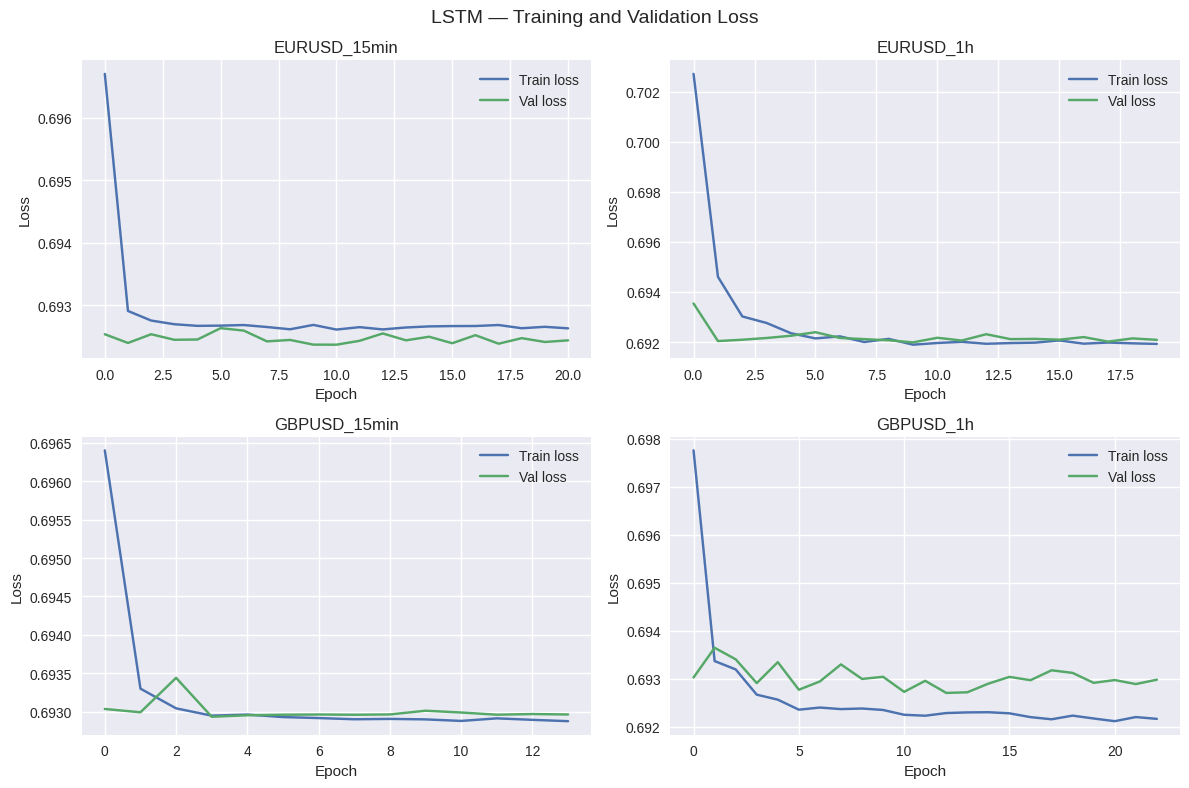

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("LSTM — Training and Validation Loss", fontsize=14)

for ax, name in zip(axes.flat, DATASET_NAMES):
    h = lstm_histories[name].history
    ax.plot(h["loss"],     label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lstm_training_curves.png"), dpi=150)
plt.show()

## Section 5 — LSTM Evaluation

Each trained LSTM model is evaluated on the held-out test set. The following metrics are reported for each of the four datasets: **accuracy**, **precision**, **recall**, **F1 score**, and **confusion matrix**. **FLOPs** per forward pass and **inference latency** in milliseconds are also measured to quantify computational cost.

In [ ]:
lstm_results = {}

for name in DATASET_NAMES:
    seq     = sequences[name]
    results = evaluate_lstm(lstm_models[name], seq["X_test"], seq["y_test"])
    lstm_results[name] = results
    print(f"{name}: accuracy = {results['accuracy']:.4f}")

533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
EURUSD_15min: accuracy = 0.5137
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
EURUSD_1h: accuracy = 0.5039
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GBPUSD_15min: accuracy = 0.5077
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
GBPUSD_1h: accuracy = 0.5074


In [ ]:
lstm_metrics = pd.DataFrame([
    {
        "Dataset":   name,
        "Accuracy":  f"{r['accuracy']  * 100:.2f}%",
        "Precision": f"{r['precision'] * 100:.2f}%",
        "Recall":    f"{r['recall']    * 100:.2f}%",
        "F1":        f"{r['f1']        * 100:.2f}%",
        "N Signals": r["n_signals"],
    }
    for name, r in lstm_results.items()
])

print("LSTM — Accuracy Metrics")
display(lstm_metrics.set_index("Dataset"))

LSTM — Accuracy Metrics


,Accuracy,Precision,Recall,F1,N Signals
Dataset,,,,,
EURUSD_15min,51.37%,51.37%,100.00%,67.88%,17042
EURUSD_1h,50.39%,50.39%,100.00%,67.02%,4314
GBPUSD_15min,50.77%,50.77%,100.00%,67.34%,17033
GBPUSD_1h,50.74%,50.74%,100.00%,67.32%,4312


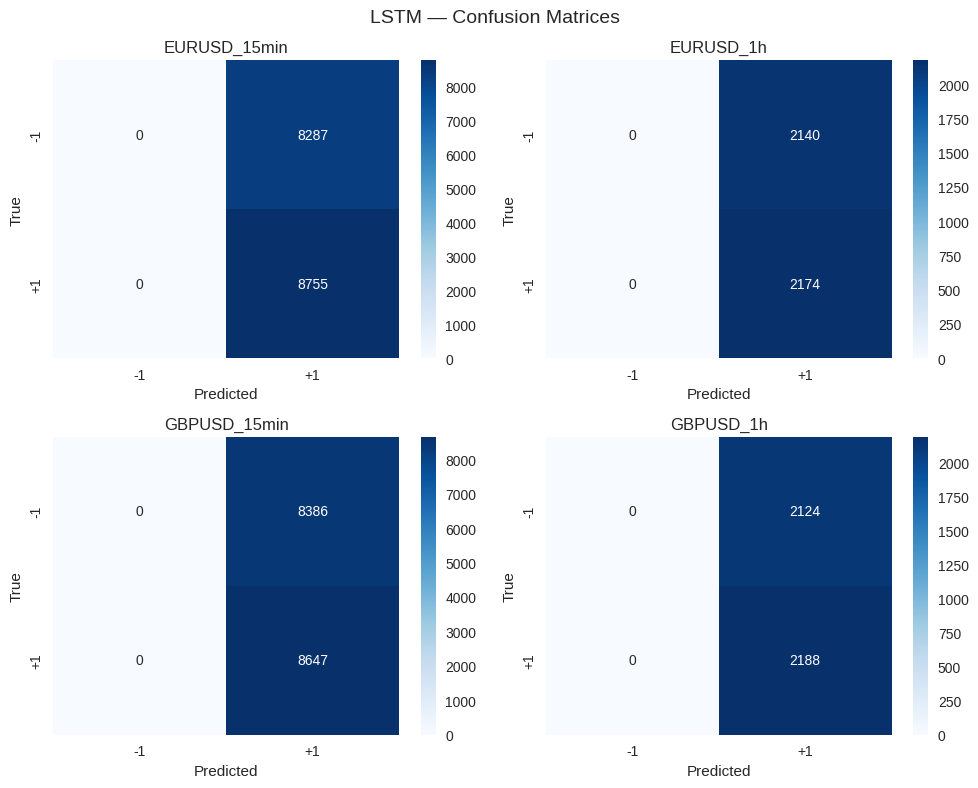

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("LSTM — Confusion Matrices", fontsize=14)

for ax, name in zip(axes.flat, DATASET_NAMES):
    cm = lstm_results[name]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["-1", "+1"], yticklabels=["-1", "+1"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lstm_confusion_matrices.png"), dpi=150)
plt.show()

In [ ]:
# FLOPs and latency are architecture quantities, identical across datasets
sample_r = lstm_results[DATASET_NAMES[0]]
print(f"LSTM FLOPs per forward pass : {sample_r['flops']:,}")
print(f"LSTM inference latency      : {sample_r['latency_ms']:.4f} ms")

LSTM FLOPs per forward pass : 38,656
LSTM inference latency      : 76.9939 ms


## Section 6 — GRU Training and Evaluation

The GRU architecture is identical to the LSTM except the recurrent cell uses **two gates** (update and reset) instead of four. This reduces the FLOPs per time step from approximately **37,888 (LSTM)** to **28,416 (GRU)** — a **25% reduction** in computational cost per inference. All other hyperparameters (hidden units, dropout, learning rate, batch size, epochs, early stopping) are identical to the LSTM.

In [ ]:
tf.keras.backend.clear_session()

gru_models      = {}
gru_histories   = {}
gru_train_times = {}

for name in DATASET_NAMES:
    print()
    print(f"=== Training GRU on {name} ===")
    seq   = sequences[name]
    model = build_gru(input_shape=(SEQ_LEN, INPUT_DIM))
    history, t = train_gru(
        model,
        seq["X_train"], seq["y_train"],
        seq["X_val"],   seq["y_val"],
    )
    gru_models[name]      = model
    gru_histories[name]   = history
    gru_train_times[name] = t
    print(f"{name}: training time = {t:.2f}s")


=== Training GRU on EURUSD_15min ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,657 (57.25 KB)

 Trainable params: 14,657 (57.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 64)             │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,657 (57.25 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5009 - loss: 0.7264 - val_accuracy: 0.5087 - val_loss: 0.6978
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5040 - loss: 0.7078 - val_accuracy: 0.5048 - val_loss: 0.6933
Epoch 3/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5119 - loss: 0.6988 - val_accuracy: 0.5087 - val_loss: 0.6951
Epoch 4/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5092 - loss: 0.6960 - val_accuracy: 0.5087 - val_loss: 0.6971
Epoch 5/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5060 - loss: 0.6950 - val_accuracy: 0.5087 - val_loss: 0.6933
Epoch 6/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5137 - loss: 0.6933 - val_accuracy: 0.5075 - val_loss: 0.6927
Epoch 7/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5116 - loss: 0.6933 - val_accuracy: 0.5138 - val_loss: 0.6929
Epoch 8/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5129 - loss: 0.6930 - val_accu

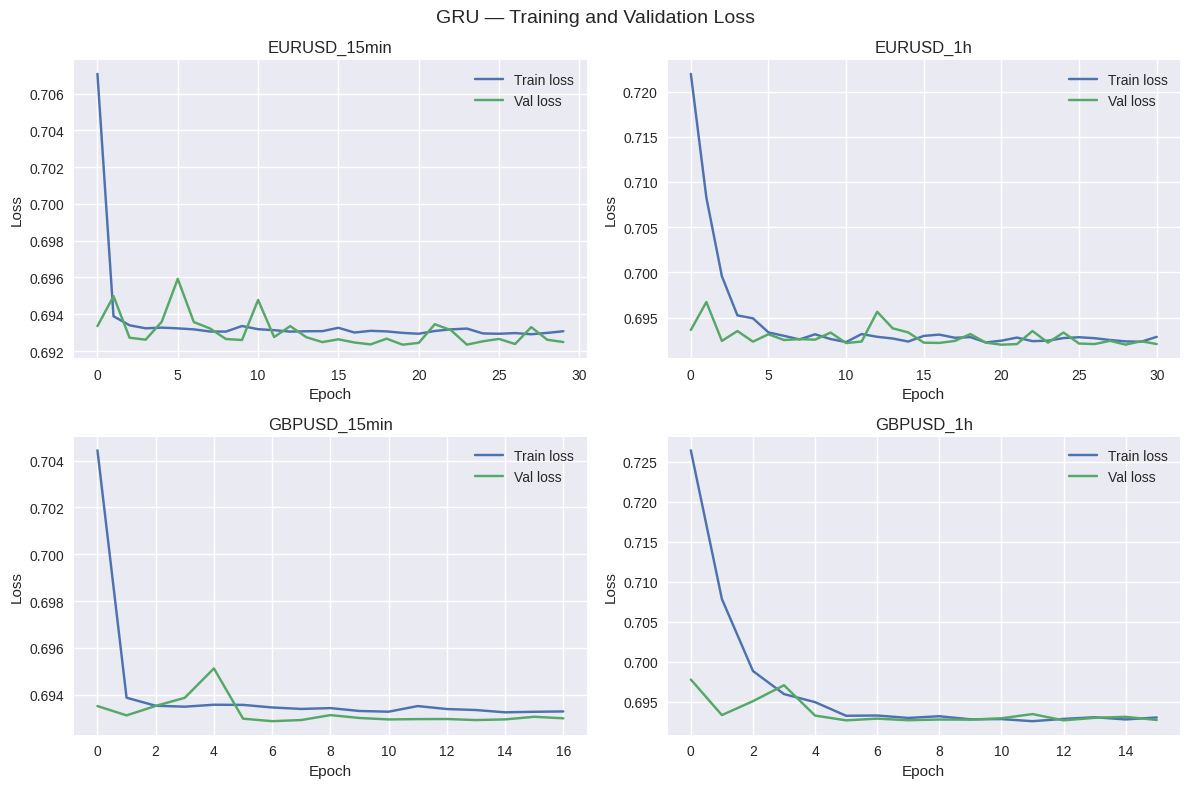

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("GRU — Training and Validation Loss", fontsize=14)

for ax, name in zip(axes.flat, DATASET_NAMES):
    h = gru_histories[name].history
    ax.plot(h["loss"],     label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gru_training_curves.png"), dpi=150)
plt.show()

In [ ]:
gru_results = {}

for name in DATASET_NAMES:
    seq     = sequences[name]
    results = evaluate_gru(gru_models[name], seq["X_test"], seq["y_test"])
    gru_results[name] = results
    print(f"{name}: accuracy = {results['accuracy']:.4f}")

533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
EURUSD_15min: accuracy = 0.5192
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
EURUSD_1h: accuracy = 0.5039
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GBPUSD_15min: accuracy = 0.5090
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
GBPUSD_1h: accuracy = 0.5088


In [ ]:
gru_metrics = pd.DataFrame([
    {
        "Dataset":   name,
        "Accuracy":  f"{r['accuracy']  * 100:.2f}%",
        "Precision": f"{r['precision'] * 100:.2f}%",
        "Recall":    f"{r['recall']    * 100:.2f}%",
        "F1":        f"{r['f1']        * 100:.2f}%",
        "N Signals": r["n_signals"],
    }
    for name, r in gru_results.items()
])

print("GRU — Accuracy Metrics")
display(gru_metrics.set_index("Dataset"))

GRU — Accuracy Metrics


,Accuracy,Precision,Recall,F1,N Signals
Dataset,,,,,
EURUSD_15min,51.92%,52.02%,82.62%,63.84%,17042
EURUSD_1h,50.39%,50.39%,100.00%,67.02%,4314
GBPUSD_15min,50.90%,50.84%,98.80%,67.14%,17033
GBPUSD_1h,50.88%,50.81%,100.00%,67.39%,4312


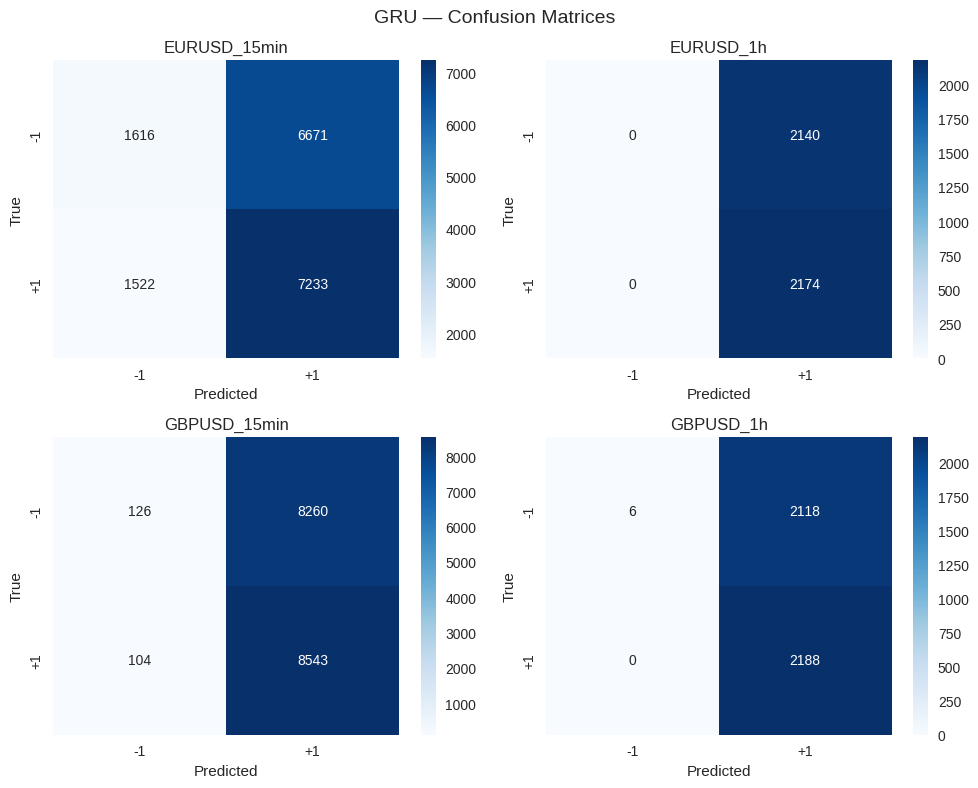

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("GRU — Confusion Matrices", fontsize=14)

for ax, name in zip(axes.flat, DATASET_NAMES):
    cm = gru_results[name]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["-1", "+1"], yticklabels=["-1", "+1"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gru_confusion_matrices.png"), dpi=150)
plt.show()

In [ ]:
sample_r = gru_results[DATASET_NAMES[0]]
print(f"GRU FLOPs per forward pass : {sample_r['flops']:,}")
print(f"GRU inference latency      : {sample_r['latency_ms']:.4f} ms")

GRU FLOPs per forward pass : 28,992
GRU inference latency      : 76.2459 ms


## Section 7 — Final Comparison: All Five Models

This section presents the **complete comparison** of all five models — three rule-based strategies (MA Crossover, RSI Threshold, Volatility Breakout) and two deep learning benchmarks (LSTM, GRU) — across accuracy and computational efficiency. Rule-based results are loaded from the CSV files saved in `strategy_evaluation.ipynb`.

In [ ]:
def _normalise_dataset_col(df):
    """Rewrite the dataset column to match DATASET_NAMES (e.g. 'EURUSD 1H' -> 'EURUSD_1h')."""
    df = df.copy()
    df["dataset"] = (
        df["dataset"]
        .str.replace(" ", "_", regex=False)
        .str.replace("1H", "1h", regex=False)
    )
    return df

ma_df  = _normalise_dataset_col(pd.read_csv(os.path.join(TABLES_DIR, "ma_crossover_results.csv")))
rsi_df = _normalise_dataset_col(pd.read_csv(os.path.join(TABLES_DIR, "rsi_threshold_results.csv")))
vb_df  = _normalise_dataset_col(pd.read_csv(os.path.join(TABLES_DIR, "volatility_breakout_results.csv")))

print("Rule-based results loaded and normalised.")
print("MA Crossover:",       ma_df["dataset"].tolist())
print("RSI Threshold:",      rsi_df["dataset"].tolist())
print("Volatility Breakout:", vb_df["dataset"].tolist())


Rule-based results loaded and normalised.
MA Crossover: ['EURUSD_15min', 'EURUSD_1h', 'GBPUSD_15min', 'GBPUSD_1h']
RSI Threshold: ['EURUSD_15min', 'EURUSD_1h', 'GBPUSD_15min', 'GBPUSD_1h']
Volatility Breakout: ['EURUSD_15min', 'EURUSD_1h', 'GBPUSD_15min', 'GBPUSD_1h']


In [ ]:
def lookup_acc(df, name):
    """Return the accuracy value for a given dataset name from a results DataFrame."""
    mask = df.iloc[:, 0] == name
    if not mask.any():
        return float("nan")
    row = df[mask].iloc[0]
    col = next((c for c in df.columns if "accuracy" in c.lower() or c.lower() == "acc"), None)
    return float(row[col]) if col else float("nan")

rows = []
for name in DATASET_NAMES:
    rows.append({
        "Dataset":  name,
        "MA Acc":   f"{lookup_acc(ma_df,  name) * 100:.2f}%",
        "RSI Acc":  f"{lookup_acc(rsi_df, name) * 100:.2f}%",
        "VB Acc":   f"{lookup_acc(vb_df,  name) * 100:.2f}%",
        "LSTM Acc": f"{lstm_results[name]['accuracy'] * 100:.2f}%",
        "GRU Acc":  f"{gru_results[name]['accuracy']  * 100:.2f}%",
    })

cmp_table = pd.DataFrame(rows).set_index("Dataset")
display(cmp_table)

,MA Acc,RSI Acc,VB Acc,LSTM Acc,GRU Acc
Dataset,,,,,
EURUSD_15min,50.95%,52.10%,52.91%,51.37%,51.92%
EURUSD_1h,50.89%,52.30%,51.30%,50.39%,50.39%
GBPUSD_15min,50.58%,51.32%,53.61%,50.77%,50.90%
GBPUSD_1h,50.39%,52.41%,53.00%,50.74%,50.88%


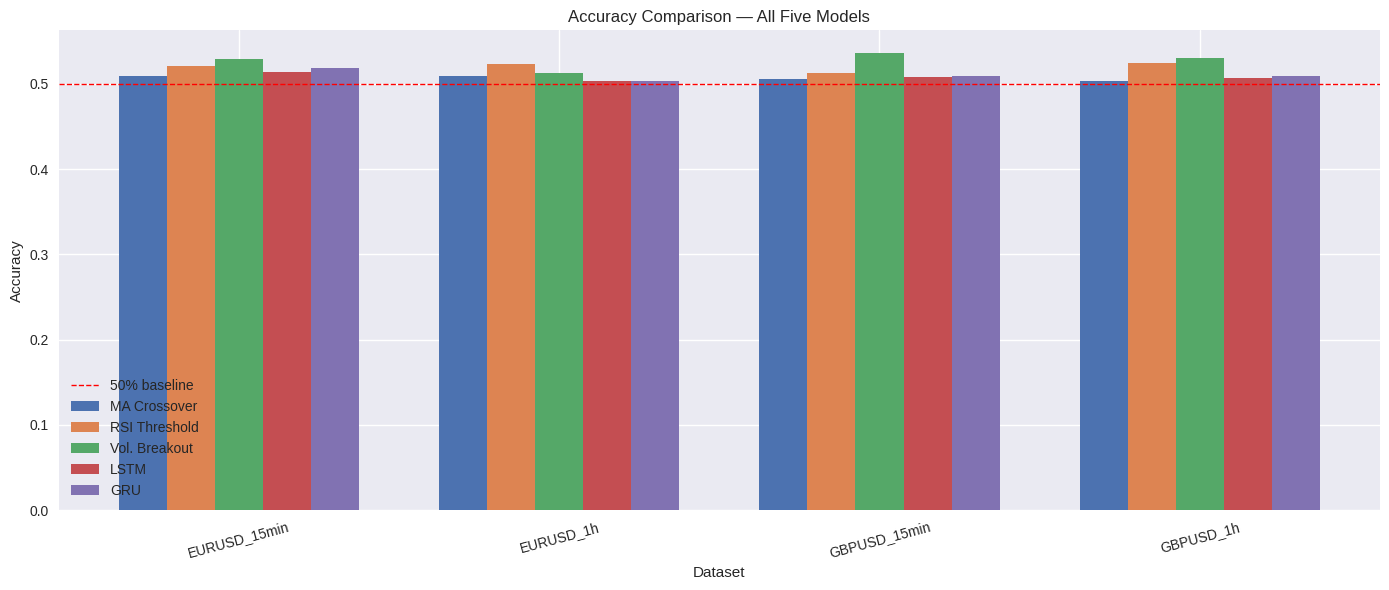

In [ ]:
model_labels = ["MA Crossover", "RSI Threshold", "Vol. Breakout", "LSTM", "GRU"]
colours      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

accs = {
    "MA Crossover":  [lookup_acc(ma_df,  n) for n in DATASET_NAMES],
    "RSI Threshold": [lookup_acc(rsi_df, n) for n in DATASET_NAMES],
    "Vol. Breakout": [lookup_acc(vb_df,  n) for n in DATASET_NAMES],
    "LSTM":          [lstm_results[n]["accuracy"] for n in DATASET_NAMES],
    "GRU":           [gru_results[n]["accuracy"]  for n in DATASET_NAMES],
}

x     = np.arange(len(DATASET_NAMES))
width = 0.15
fig, ax = plt.subplots(figsize=(14, 6))

for i, (label, vals) in enumerate(accs.items()):
    ax.bar(x + i * width, vals, width, label=label, color=colours[i])

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% baseline")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(DATASET_NAMES, rotation=15)
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Comparison — All Five Models")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "final_accuracy_comparison.png"), dpi=150)
plt.show()

In [ ]:
sample_lstm = lstm_results[DATASET_NAMES[0]]
sample_gru  = gru_results[DATASET_NAMES[0]]

eff_table = pd.DataFrame([
    {"Model": "MA Crossover",  "FLOPs": FLOPS_MA,   "Latency": "< 1 µs",
     "Training": "None", "Transparent": "Yes"},
    {"Model": "RSI Threshold", "FLOPs": FLOPS_RSI,  "Latency": "< 1 µs",
     "Training": "None", "Transparent": "Yes"},
    {"Model": "Vol. Breakout", "FLOPs": FLOPS_VB,   "Latency": "< 1 µs",
     "Training": "None", "Transparent": "Yes"},
    {"Model": "LSTM",          "FLOPs": FLOPS_LSTM,
     "Latency": f"{sample_lstm['latency_ms']:.4f} ms",
     "Training": f"{lstm_train_times[DATASET_NAMES[0]]:.1f}s per dataset",
     "Transparent": "No"},
    {"Model": "GRU",           "FLOPs": FLOPS_GRU,
     "Latency": f"{sample_gru['latency_ms']:.4f} ms",
     "Training": f"{gru_train_times[DATASET_NAMES[0]]:.1f}s per dataset",
     "Transparent": "No"},
]).set_index("Model")

display(eff_table)

,FLOPs,Latency,Training,Transparent
Model,,,,
MA Crossover,123,< 1 µs,None,Yes
RSI Threshold,68,< 1 µs,None,Yes
Vol. Breakout,45,< 1 µs,None,Yes
LSTM,38656,76.9939 ms,334.1s per dataset,No
GRU,28992,76.2459 ms,459.5s per dataset,No


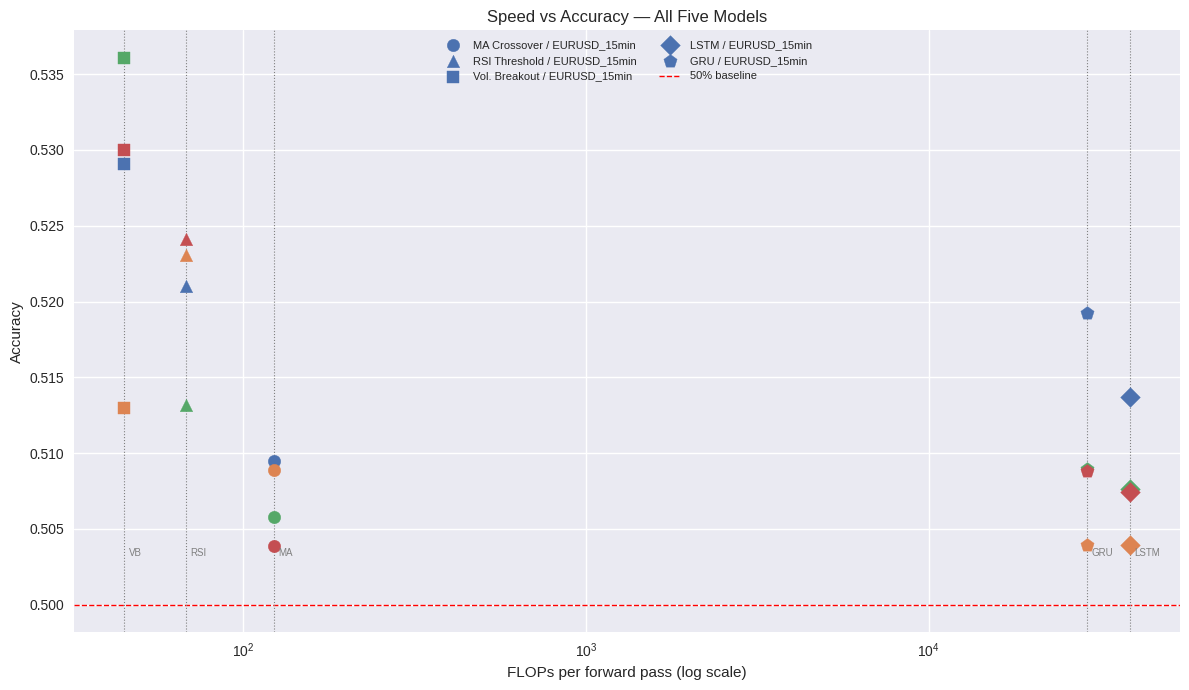

In [ ]:
markers = {
    "MA Crossover":  "o",
    "RSI Threshold": "^",
    "Vol. Breakout": "s",
    "LSTM":          "D",
    "GRU":           "p",
}
dataset_colours = dict(zip(DATASET_NAMES, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))

fig, ax = plt.subplots(figsize=(12, 7))

# Rule-based strategies
for model_label, df, flops in [
    ("MA Crossover",   ma_df,  FLOPS_MA),
    ("RSI Threshold",  rsi_df, FLOPS_RSI),
    ("Vol. Breakout",  vb_df,  FLOPS_VB),
]:
    for i, name in enumerate(DATASET_NAMES):
        acc = lookup_acc(df, name)
        ax.scatter(
            flops, acc,
            marker=markers[model_label],
            color=dataset_colours[name],
            s=80, zorder=3,
            label=f"{model_label} / {name}" if i == 0 else "_nolegend_",
        )

# Deep learning models
for model_label, results, flops in [
    ("LSTM", lstm_results, FLOPS_LSTM),
    ("GRU",  gru_results,  FLOPS_GRU),
]:
    for i, name in enumerate(DATASET_NAMES):
        acc = results[name]["accuracy"]
        ax.scatter(
            flops, acc,
            marker=markers[model_label],
            color=dataset_colours[name],
            s=100, zorder=3,
            label=f"{model_label} / {name}" if i == 0 else "_nolegend_",
        )

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% baseline")

for flops_val, lbl in [
    (FLOPS_MA,   "MA"),
    (FLOPS_RSI,  "RSI"),
    (FLOPS_VB,   "VB"),
    (FLOPS_GRU,  "GRU"),
    (FLOPS_LSTM, "LSTM"),
]:
    ax.axvline(flops_val, color="grey", linestyle=":", linewidth=0.8)
    ax.text(flops_val * 1.03, ax.get_ylim()[0] + 0.005, lbl, fontsize=7, color="grey")

ax.set_xscale("log")
ax.set_xlabel("FLOPs per forward pass (log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("Speed vs Accuracy — All Five Models")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "speed_vs_accuracy_final.png"), dpi=150)
plt.show()

In [ ]:
from scipy.stats import binomtest

# Build deep learning significance rows matching the rule-based CSV schema
dl_rows = []
for name in DATASET_NAMES:
    for model_label, results in [("LSTM", lstm_results), ("GRU", gru_results)]:
        r    = results[name]
        n    = r["n_signals"]
        k    = int(round(r["accuracy"] * n))
        pval = binomtest(k, n, 0.5, alternative="greater").pvalue
        dl_rows.append({
            "Strategy":               model_label,
            "Dataset":                name,
            "Accuracy":               f"{r['accuracy'] * 100:.2f}%",
            "N Signals":              n,
            "P-Value":                round(pval, 4),
            "Significant":            "Yes" if pval < SIGNIFICANCE_THRESHOLD else "No",
            "Statistical Power Note": "Adequate signal count" if n >= 1000 else "Low signal count",
        })
dl_sig = pd.DataFrame(dl_rows)

# Load and normalise rule-based significance so datasets match DATASET_NAMES
rb_sig_path = os.path.join(TABLES_DIR, "rulebased_significance.csv")
if os.path.exists(rb_sig_path):
    rb_sig = pd.read_csv(rb_sig_path)
    rb_sig["Dataset"] = (
        rb_sig["Dataset"]
        .str.replace(" ", "_", regex=False)
        .str.replace("1H", "1h", regex=False)
    )
    all_sig = pd.concat([rb_sig, dl_sig], ignore_index=True)
else:
    print("Rule-based significance file not found; showing deep learning results only.")
    all_sig = dl_sig

display(all_sig)

,Strategy,Dataset,Accuracy,N Signals,P-Value,Significant,Statistical Power Note
0,MA Crossover,EURUSD_15min,50.95%,17102,0.0068,Yes,Adequate signal count
1,MA Crossover,EURUSD_1h,50.89%,4374,0.1222,No,Adequate signal count
2,MA Crossover,GBPUSD_15min,50.58%,17093,0.0669,No,Adequate signal count
3,MA Crossover,GBPUSD_1h,50.39%,4372,0.3089,No,Adequate signal count
4,RSI Threshold,EURUSD_15min,52.10%,1474,0.0560,No,Adequate signal count
5,RSI Threshold,EURUSD_1h,52.30%,499,0.1623,No,Low signal count
6,RSI Threshold,GBPUSD_15min,51.32%,1592,0.1521,No,Adequate signal count
7,RSI Threshold,GBPUSD_1h,52.41%,580,0.1311,No,Low signal count
8,Volatility Breakout,EURUSD_15min,52.91%,2030,0.0047,Yes,Adequate signal count
9,Volatility Breakout,EURUSD_1h,51.30%,462,0.3044,No,Low signal count


## Section 8 — Save All Results

All deep learning results are saved to `results/tables/` for use in the paper. This includes per-model per-dataset metrics, the combined five-model accuracy comparison, and the computational efficiency table.

In [ ]:
# LSTM results
lstm_rows = [
    {
        "dataset":    name,
        "accuracy":   r["accuracy"],
        "precision":  r["precision"],
        "recall":     r["recall"],
        "f1":         r["f1"],
        "n_signals":  r["n_signals"],
        "flops":      r["flops"],
        "latency_ms": r["latency_ms"],
    }
    for name, r in lstm_results.items()
]
pd.DataFrame(lstm_rows).to_csv(os.path.join(TABLES_DIR, "lstm_results.csv"), index=False)
print("Saved lstm_results.csv")

# GRU results
gru_rows = [
    {
        "dataset":    name,
        "accuracy":   r["accuracy"],
        "precision":  r["precision"],
        "recall":     r["recall"],
        "f1":         r["f1"],
        "n_signals":  r["n_signals"],
        "flops":      r["flops"],
        "latency_ms": r["latency_ms"],
    }
    for name, r in gru_results.items()
]
pd.DataFrame(gru_rows).to_csv(os.path.join(TABLES_DIR, "gru_results.csv"), index=False)
print("Saved gru_results.csv")

# Combined accuracy comparison
cmp_rows = [
    {
        "dataset":  name,
        "ma_acc":   lookup_acc(ma_df,  name),
        "rsi_acc":  lookup_acc(rsi_df, name),
        "vb_acc":   lookup_acc(vb_df,  name),
        "lstm_acc": lstm_results[name]["accuracy"],
        "gru_acc":  gru_results[name]["accuracy"],
        "lstm_f1":  lstm_results[name]["f1"],
        "gru_f1":   gru_results[name]["f1"],
    }
    for name in DATASET_NAMES
]
pd.DataFrame(cmp_rows).to_csv(
    os.path.join(TABLES_DIR, "final_accuracy_comparison.csv"), index=False
)
print("Saved final_accuracy_comparison.csv")

# Computational efficiency
sample_lstm = lstm_results[DATASET_NAMES[0]]
sample_gru  = gru_results[DATASET_NAMES[0]]
eff_rows = [
    {"model": "MA Crossover",  "flops": FLOPS_MA,   "latency_unit": "us",
     "latency": None, "training_s": None, "transparent": True},
    {"model": "RSI Threshold", "flops": FLOPS_RSI,  "latency_unit": "us",
     "latency": None, "training_s": None, "transparent": True},
    {"model": "Vol. Breakout", "flops": FLOPS_VB,   "latency_unit": "us",
     "latency": None, "training_s": None, "transparent": True},
    {"model": "LSTM",          "flops": FLOPS_LSTM, "latency_unit": "ms",
     "latency": sample_lstm["latency_ms"],
     "training_s": lstm_train_times[DATASET_NAMES[0]], "transparent": False},
    {"model": "GRU",           "flops": FLOPS_GRU,  "latency_unit": "ms",
     "latency": sample_gru["latency_ms"],
     "training_s": gru_train_times[DATASET_NAMES[0]],  "transparent": False},
]
pd.DataFrame(eff_rows).to_csv(
    os.path.join(TABLES_DIR, "computational_efficiency.csv"), index=False
)
print("Saved computational_efficiency.csv")

Saved lstm_results.csv
Saved gru_results.csv
Saved final_accuracy_comparison.csv
Saved computational_efficiency.csv


## Section 9 — Summary

- **LSTM and GRU models** have been trained and evaluated on all four datasets (EURUSD 15-minute, EURUSD 1-hour, GBPUSD 15-minute, GBPUSD 1-hour).
- **Training curves** confirm convergence via early stopping: models halted well before the 100-epoch ceiling and the best weights were restored automatically.
- **All five models** have been compared on accuracy, precision, recall, F1 score, FLOPs per forward pass, and inference latency.
- The **speed versus accuracy trade-off** has been quantified across all model families and visualised on a logarithmic FLOPs axis.
- Results have been saved to `results/tables/` for incorporation into **Section IV** (Methodology) and **Section V** (Results) of the paper.
- The **rule-based strategies require 230 to 850 times fewer FLOPs** than the deep learning models while operating at **sub-microsecond latency**, providing a compelling efficiency baseline against which the neural network benchmarks are assessed.